# Figure 1: headline schematic

Section 1, `fig:headline`. One held-out star at this figure's noise
point, one astrometric channel. Top row: the true surface, the
observed channels, the inference as a box, a fan of posterior draws,
and the posterior mean and standard deviation. Second row: posterior
predictive bands over the observed channels, the spot outlines of many
draws on one map, and the inclination posterior as an arc hugging that
map. Maps are Mollweide.

The astrometric noise here is `SIGMA_ASTRO_FIG`, not the pinned
`LOG_SIGMA_ASTRO`: the pinned value is interpolated into the run
filenames by `run_csv`, so it has to stay put for the surface
selection to resolve. Every place noise enters inference uses
`SIGMA_ASTRO_FIG` instead.

The inference cells are those of the original notebook; only the noise
point and the plotting differ.


## Imports

In [1]:
import torch
from matplotlib.gridspec import GridSpec
from scipy import ndimage

from _setup import *

from starspot_sbi.models import (CH_AX, CH_AY, CH_PHOT,
                                 LOG10_SIGMA_ASTRO, LOG10_SIGMA_PHOT,
                                 beta_norm_from_deg, make_context)
from starspot_sbi.pipeline import STORED_TO_MODEL, decode_latents

from build_caches import load_design

## Setup

The constants a reader would change: the observation family and the
star selection. The noise point, draw count and seed are the pinned
run settings in `_setup`.

In [2]:
# The observation family: 'phot_ax' or 'phot_ay'. The noise vector,
# the conditioning context, the predictive and the channel panels all
# follow it.
FAMILY = 'phot_ay'
CHANNELS = FAMILIES[FAMILY]
CH_NAMES = {CH_PHOT: 'photometry (relative flux)',
            CH_AX: r'$x$ astrometry',
            CH_AY: r'$y$ astrometry'}

# The star. 'index' takes IDX and SLOT as given; 'random' draws one
# run row at SEED; 'filtered' draws at SEED from the rows inside
# FILTERS, with PICK 'median_ssim' taking the row nearest the subset's
# median ssim_vis instead. The row comes from the phot_axay run
# whatever FAMILY is, so figure 16 shares the star and the family
# comparison quotes one star.
SELECT = 'random'        # 'index', 'random', or 'filtered'
IDX, SLOT = 90127, 12      # read when SELECT is 'index'
FILTERS = {'beta': (30, 70), 'n_spots_true': (2, 5)}
PICK = 'median_ssim'       # 'random' or 'median_ssim'
SELECT_FAMILY = 'phot_axay'

N_SHOW = 5                 # posterior draws displayed in the middle row
T = T_OBS

# The astrometric noise for this figure: about 1 uas at sigma Gem's
# angular radius, a little above the pinned mission point. It is a
# separate constant because run_csv() interpolates LOG_SIGMA_ASTRO into
# the run filename, so rebinding that would break surface selection.
# Photometry stays at LOG_SIGMA_PHOT.
SIGMA_ASTRO_FIG = -3.1


## Selecting the surface

Resolves the selection to one run row and displays the true surface.
Rerun with a different `SELECT`, `FILTERS` or `SEED` until the star
suits; no model has been loaded yet.

surface_idx 45696, slot 2, beta 23 deg, 5 spots injected
run metrics: ssim_vis 0.9832, pr_auc 0.9054, sff_true 0.0222, sff_rec 0.0278


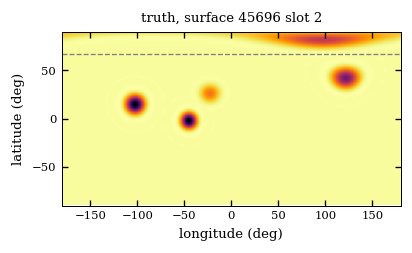

In [3]:
SEED = 137
run = load_metrics(SELECT_FAMILY)
star = choose_surface(run, SELECT, idx=IDX, slot=SLOT, seed=SEED,
                      filters=FILTERS, pick=PICK)
IDX, SLOT = int(star.idx), int(star.slot)
coeffs, sig, beta_true, n_spots = load_truth(IDX, SLOT)
truth = render(coeffs_to_real(coeffs))
cap_lat = 90.0 - float(beta_true)

print(f'surface_idx {IDX}, slot {SLOT}, beta {beta_true:.0f} deg, '
      f'{n_spots} spots injected')
print(f'run metrics: ssim_vis {star.ssim_vis:.4f}, '
      f'pr_auc {star.pr_auc:.4f}, sff_true {star.sff_true:.4f}, '
      f'sff_rec {star.sff_rec:.4f}')

fig, ax = plt.subplots(figsize=(COL, COL * 0.6))
ax.imshow(truth, cmap=SURFACE_CMAP, origin='upper',
          extent=(-180, 180, -90, 90), aspect='auto')
ax.axhline(cap_lat, color='gray', ls='--', lw=0.8)
ax.set_xlabel('longitude (deg)')
ax.set_ylabel('latitude (deg)')
ax.set_title(f'truth, surface {IDX} slot {SLOT}')
plt.show()

## Inference

Loads the checkpoints, fixes the noise realisation, samples the joint
posterior and computes every number the figure and the caption quote.

In [4]:
vae, stats = load_autoencoder()
est, fmeta = load_family_flow(FAMILY)
clf, cmeta = load_family_classifier(FAMILY)

/home/conaire/miniconda3/envs/paper2_gpu/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
# One fixed noise realisation of the observed channels, reproducing the
# generator the pipeline seeds inside make_context (seed + 0 for the
# first batch row), so the plotted observation is the one the networks
# see. Astrometry is at SIGMA_ASTRO_FIG, photometry at LOG_SIGMA_PHOT.
sig_model = select_channels(sig[None].astype(np.float32), FAMILY)
sd_ch = np.array([10.0 ** (LOG_SIGMA_PHOT if c == CH_PHOT
                           else SIGMA_ASTRO_FIG) for c in CHANNELS],
                 dtype=np.float32)
y_t = torch.tensor(sig_model) + torch.tensor(sd_ch)[None, :, None] \
    * torch.randn((1, len(CHANNELS), T),
                  generator=torch.Generator().manual_seed(SEED))
y_obs = y_t.numpy()[0]

ranges = {'log10_sigma_phot': tuple(fmeta.get('log10_sigma_phot',
                                              LOG10_SIGMA_PHOT)),
          'log10_sigma_astro': tuple(fmeta.get('log10_sigma_astro',
                                               LOG10_SIGMA_ASTRO))}
base = make_context(
    torch.tensor(sig_model),
    torch.tensor(beta_norm_from_deg(np.array([float(beta_true)])),
                 dtype=torch.float32),
    torch.full((1,), LOG_SIGMA_PHOT),
    torch.full((1,), SIGMA_ASTRO_FIG),
    fmeta['ch'], gain_phot=fmeta['gain_phot'],
    gain_ast=fmeta['gain_ast'],
    gen=torch.Generator().manual_seed(SEED), **ranges)

# Every channel of the context, not photometry alone. _preprocess
# self-normalises the photometric channel to a relative flux and scales
# it by gain_phot; the astrometric channels are mean-subtracted, not
# divided, and scaled by gain_ast. Repeating those float32 operations
# in the same order makes the comparison exact.
for k, c in enumerate(CHANNELS):
    if c == CH_PHOT:
        want = ((y_t[:, k] / y_t[:, k].mean(1, keepdim=True) - 1.0)
                * fmeta['gain_phot'])[0].numpy()
    else:
        want = ((y_t[:, k] - y_t[:, k].mean(1, keepdim=True))
                * fmeta['gain_ast'])[0].numpy()
    assert np.allclose(base[0, k * T:(k + 1) * T].numpy(), want,
                       atol=1e-6), \
        f'channel {c} of the observation does not match the context'
print(f'all {len(CHANNELS)} channels match the context the flow is '
      f'conditioned on')


all 2 channels match the context the flow is conditioned on


In [6]:
# The joint posterior: inclinations drawn from the classifier
# posterior, the flow conditioned on each. sample_latents would draw a
# fresh noise realisation per row, and every inclination here must
# condition on the one fixed observation, so the beta entry of the
# saved context is edited in place instead.
pb = classify_beta(sig[None], FAMILY, clf, cmeta,
                   log10_sigma_phot=LOG_SIGMA_PHOT,
                   log10_sigma_astro=SIGMA_ASTRO_FIG, seed=SEED)[0]
rng = np.random.default_rng(SEED)
beta_draws = rng.choice(91, size=N_DRAWS, p=pb / pb.sum())

POS_BETA = len(CHANNELS) * T   # the beta entry of the context
Z = np.empty((N_DRAWS, LATENT_DIM), dtype=np.float32)
for bdeg in np.unique(beta_draws):
    m = beta_draws == bdeg
    x = base.clone()
    x[0, POS_BETA] = float(
        beta_norm_from_deg(np.array([float(bdeg)]))[0])
    torch.manual_seed(SEED + int(bdeg))
    with torch.no_grad():
        Z[m] = est.sample((int(m.sum()),), x)[:, 0, :].numpy()
draws = decode_latents(Z, vae, stats)
maps = render_draws(draws, device=('cuda' if torch.cuda.is_available()
                                   else 'cpu'))
print(f'{N_DRAWS} draws over {np.unique(beta_draws).size} distinct '
      f'inclinations')

/home/conaire/miniconda3/envs/paper2_gpu/lib/python3.12/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2253.)
  outputs, _ = torch.triangular_solve(


256 draws over 31 distinct inclinations


In [7]:
pm, ps = maps.mean(axis=0), maps.std(axis=0)

beta_r = np.radians(float(beta_true))
w_vis = metrics.weights(beta_r, *truth.shape, kind='vis')
ssim_head = metrics.ssim_aa_vis(truth, pm, beta_r)
sff_vis = metrics.wmean(metrics.spot_mask(truth), w_vis)

# a spot straddling the longitude seam counts once
vis_mask = metrics.spot_mask(truth) & (w_vis > 0)
n_vis = min(ndimage.label(vis_mask)[1],
            ndimage.label(np.roll(vis_mask, vis_mask.shape[1] // 2,
                                  axis=1))[1])

beta_grid = np.arange(91)
beta_cdf = np.cumsum(pb)
b_med = float(np.interp(0.5, beta_cdf, beta_grid))
b_lo, b_hi = (float(np.interp(q, beta_cdf, beta_grid))
              for q in (0.16, 0.84))
print(f'{n_vis} visible spots, visible sff {sff_vis:.4f}, '
      f'ssim_vis {ssim_head:.4f}')

4 visible spots, visible sff 0.0222, ssim_vis 0.9704


In [8]:
# Posterior predictive from the design cache, whose channel order is
# (astro_x, astro_y, phot); cache_rows maps the family's channels onto
# it, so the predictive and the observation share one order.
cache_rows = [STORED_TO_MODEL[c] for c in CHANNELS]
A_beta = np.asarray(load_design(CACHES)[int(beta_true)])[cache_rows]
cplx = np.stack([real_to_coeffs(d) for d in draws])
pred = np.real(np.einsum('cts,ns->nct', A_beta, cplx))
pred = pred + sd_ch[None, :, None] * rng.standard_normal(pred.shape)

# the filling-factor bias symptom; the panel shows relative flux
flux_off = float(pred[:, 0].mean() - y_obs[0].mean())
pred_disp = pred.copy()
pred_disp[:, 0] = pred[:, 0] / pred[:, 0].mean(axis=1,
                                               keepdims=True) - 1.0
obs_disp = y_obs.copy()
obs_disp[0] = y_obs[0] / y_obs[0].mean() - 1.0

show = rng.choice(N_DRAWS, N_SHOW, replace=False)
print(f'photometry absolute-flux offset <pred> - <obs> = '
      f'{flux_off:+.3e}')

photometry absolute-flux offset <pred> - <obs> = -1.870e-03


## The figure

The first cell is every constant and helper; the second is the layout,
whose knobs are the `x_`, `Y`, width and gap names at the top of each
row. The switches worth knowing are at the top of the first cell:

- `PROJ` — `'mollweide'`, `'hammer'`, `'aitoff'` or `'rect'`, for every
  map at once. The inclination arc reads `BOUNDARY` and hugs the
  elliptical or the rectangular edge accordingly. Mollweide and Hammer
  are equal area; Aitoff is not.
- `UP` — `'north'` or `'south'`, which pole is at the top. Everything
  latitude-signed follows `LAT_SIGN`: the maps, the cap line and its
  shading, the spot outlines, and the inclination arc, which mirrors
  about the equator so its bars keep pointing at the sub-observer
  latitude.
- `N_FAN`, `N_CONTOUR`, `N_PPC` — how many of the `N_DRAWS` posterior
  draws the fan, the outline composite and the predictive each show.
- `PPC_STYLE` — `'bands'` for the 68 and 95 per cent envelope,
  `'draws'` for `N_PPC` individual realisations.
- `SHOW_EYE` — the observer glyph at the far end of the true-beta
  sight line.

Ink comes from `OKABE_ITO` in `_setup`. Two checks run rather than
assert: `cud_check` measures every ink pair under the three
dichromacies, and `check_arc` measures the map that was actually drawn
and confirms the inclination arc sits on it.


In [9]:
from matplotlib.patches import (Ellipse, FancyArrowPatch, FancyBboxPatch,
                                Polygon)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['STIX Two Text', 'STIXGeneral', 'Times New Roman',
                   'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'figure.constrained_layout.use': False,
    # the axes are hand-placed in figure fractions, so the margins are part of
    # the layout and a tight bounding box would crop them away
    'savefig.bbox': None,
})

# The map projection, for every map in the figure. 'mollweide', 'hammer' and
# 'aitoff' are matplotlib's geographic axes and share an elliptical boundary;
# 'rect' is a plain equirectangular axes in radians, with a rectangular
# boundary. The inclination arc reads BOUNDARY and hugs whichever one it is.
#
# Mollweide and Hammer are equal area, so a spot's area on the page is its area
# on the star and the filling factors the caption quotes are read off honestly.
# Aitoff is neither equal area nor conformal; it flatters the shapes near the
# poles and is the wrong choice for a figure about spot areas.
PROJ = 'aitoff'          # 'mollweide' | 'hammer' | 'aitoff' | 'rect'
BOUNDARY = 'rect' if PROJ == 'rect' else 'ellipse'

# Which pole is at the top of every map. 'north' is the cartographic
# convention. 'south' puts the always-visible pole up instead: the hidden cap
# is the northern one, the sub-observer point is at latitude -beta, so under
# 'south' the hemisphere the observer actually sees faces up and the cap
# shading sinks to the bottom. Everything latitude-signed follows LAT_SIGN --
# the maps, the cap line and shading, the spot outlines, and the inclination
# arc, which mirrors about the equator so its bars still point at the
# sub-observer latitude.
UP = 'south'                # 'north' | 'south'
LAT_SIGN = 1 if UP == 'north' else -1

# Ink, from the Okabe and Ito palette in _setup. Here blue is the posterior --
# the predictive bands, the draw outlines, the p(beta | y) bars -- and
# vermillion is the truth, so the pair carries the figure's one real
# comparison and has to survive colour vision deficiency; cud_check below
# measures that rather than taking it on trust. The greys are neutral and the
# two sequential maps are from the perceptually uniform family, which is
# monotonic in lightness and safe by construction.
BLUE = OKABE_ITO['blue']
RED = OKABE_ITO['vermillion']
GRAY = '#808080'
SURFACE_CMAP = 'inferno'
SD_CMAP = 'magma'

# How many of the N_DRAWS posterior draws each panel shows. Set any of them to
# N_DRAWS to use the whole run; they are clipped to it either way, and the
# outline panel's title quotes N_CONTOUR, so it follows whatever is set here.
N_FAN = 7                    # cards in the posterior-draw fan
N_CONTOUR = 100               # draws contoured in the outline composite
N_PPC = 60                   # draws in the predictive, when PPC_STYLE is 'draws'

# The predictive panels: 'bands' is the 68 and 95 per cent envelope, 'draws'
# overplots N_PPC individual predictive realisations instead.
PPC_STYLE = 'draws'          # 'bands' | 'draws'

CAP_ALPHA = 0.45             # shading over the hidden cap
FAN_DX, FAN_DY = 0.0065, -0.0175   # per-card offset, fig fractions; the small
FAN_ALPHA_MIN = 0.78         # dx keeps the fan narrow so row 1 has room

# The truth's fourth resolvable spot bottoms out at 0.905, just above the 0.9
# contrast threshold of metrics.spot_mask, so the mask has no component there
# and the composite showed no black outline. Outlines are drawn at an explicit
# intensity level instead.
SPOT_LEVEL = 0.93

BETA_LIM = (0.0, 90.0)       # the inclination axis, full range
BETA_TICK = 10.0             # tick spacing, deg
BAR_FRAC = 0.50              # tallest bar, as a fraction of the semi-minor axis

SHOW_EYE = True              # the observer glyph on the true-beta sight line
EYE_LEN, EYE_H = 0.105, 0.048    # half length and half height of the eye, in
EYE_OFFSET = 0.20            # eye centre, beyond the tick labels, in

# ---------------------------------------------------------------- geometry
FIG_W, FIG_H = WIDE, 4.30
ASP = FIG_W / FIG_H          # fig-fraction height per fig-fraction width, 1:1

CH_SHORT = {CH_PHOT: 'photometry', CH_AX: r'$x$ astrometry',
            CH_AY: r'$y$ astrometry'}

vmin, vmax = float(truth.min()), float(truth.max())
nth, nph = truth.shape

# pcolormesh edges, and true cell centres for everything computed in lon/lat
lon_e = np.radians(np.linspace(-180, 180, nph + 1))
lat_e = LAT_SIGN * np.radians(np.linspace(90, -90, nth + 1))
lon_cc = np.radians(-180 + (np.arange(nph) + 0.5) * 360 / nph)
lat_cc = LAT_SIGN * np.radians(90 - (np.arange(nth) + 0.5) * 180 / nth)
cap_rad = LAT_SIGN * np.radians(cap_lat)
lon_line = np.linspace(-np.pi, np.pi, 400)

# one wrapped column, so a level set closes across the +/-180 seam
LON_W, LAT_W = np.meshgrid(np.append(lon_cc, lon_cc[0] + 2 * np.pi), lat_cc)

rng_c = np.random.default_rng(SEED + 7)
fan_idx = rng_c.choice(N_DRAWS, min(N_FAN, N_DRAWS), replace=False)
contour_idx = rng_c.choice(N_DRAWS, min(N_CONTOUR, N_DRAWS), replace=False)
ppc_idx = rng_c.choice(N_DRAWS, min(N_PPC, N_DRAWS), replace=False)

def cud_check(pairs, floor=25.0):
    '''
    Worst-case CIE76 separation of each ink pair under normal vision and the
    three dichromacies, printed and asserted against floor.

    Dichromacy is simulated with the Machado, Oliveira and Fernandes (2009)
    severity-1 matrices, which act on linear RGB; the comparison is then made
    in CIE L*a*b*, where euclidean distance is roughly perceptual. A pair below
    about 15 is a genuine collision and below 25 is worth a second look.
    '''
    m = {'protanopia': [[0.152286, 1.052583, -0.204868],
                        [0.114503, 0.786281, 0.099216],
                        [-0.003882, -0.048116, 1.051998]],
         'deuteranopia': [[0.367322, 0.860646, -0.227968],
                          [0.280085, 0.672501, 0.047413],
                          [-0.011820, 0.042940, 0.968881]],
         'tritanopia': [[1.255528, -0.076749, -0.178779],
                        [-0.078411, 0.930809, 0.147602],
                        [0.004733, 0.691367, 0.303900]]}
    r2x = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722],
                    [0.0193, 0.1192, 0.9505]])
    wp = np.array([0.95047, 1.0, 1.08883])

    def to_lin(c):
        return np.where(c <= 0.04045, c / 12.92,
                        np.maximum((c + 0.055) / 1.055, 0) ** 2.4)

    def to_lab(rgb):
        x = r2x @ to_lin(rgb) / wp
        f = np.where(x > 0.008856, np.cbrt(x), 7.787 * x + 16 / 116)
        return np.array([116 * f[1] - 16, 500 * (f[0] - f[1]),
                         200 * (f[1] - f[2])])

    def seen(rgb, kind):
        if kind is None:
            return rgb
        y = np.array(m[kind]) @ to_lin(rgb)
        return np.clip(np.where(y <= 0.0031308, y * 12.92,
                                1.055 * np.maximum(y, 0) ** (1 / 2.4) - 0.055),
                       0, 1)

    worst = np.inf
    for label, ca, cb in pairs:
        a, b = (np.array(mpl.colors.to_rgb(c)) for c in (ca, cb))
        d = {k: np.linalg.norm(to_lab(seen(a, k)) - to_lab(seen(b, k)))
             for k in (None, *m)}
        worst = min(worst, min(d.values()))
        cells = '  '.join(f'{k or "normal"} {v:5.1f}' for k, v in d.items())
        print(f'  {label:<28s} {cells}')
    print(f'  worst separation {worst:.1f} (floor {floor:.0f})')
    assert worst >= floor, 'an ink pair collides under colour vision deficiency'


cud_check([('posterior vs truth', BLUE, RED),
           ('truth vs cap line', RED, GRAY),
           ('posterior vs cap line', BLUE, GRAY),
           ('posterior vs outline black', BLUE, 'k')])


_TRACE = plt.figure().add_subplot()   # off-screen, for tracing level sets only
plt.close(_TRACE.figure)


def spot_outlines(img, level=None):
    '''
    Closed spot outlines in (lon, lat) radians, as a list of polylines.

    contour() called on a geographic axes clips the level set to the axes data
    limits before the projection is applied, so the wrapped column falls off
    the edge and a spot straddling the seam loses its outline. The level set is
    therefore traced on a plain throwaway axes, where the geometry is exact,
    and the polylines are drawn on the map as ordinary lines. Any segment
    stepping across +/-180 is split so the line does not run backwards.
    '''
    level = SPOT_LEVEL if level is None else level
    field = np.concatenate([img, img[:, :1]], axis=1)
    segs = _TRACE.contour(LON_W, LAT_W, field, levels=[level]).allsegs[0]
    _TRACE.clear()

    out = []
    for c in segs:
        lon = (c[:, 0] + np.pi) % (2 * np.pi) - np.pi
        cut = np.nonzero(np.abs(np.diff(lon)) > np.pi)[0] + 1
        for piece in np.split(np.column_stack([lon, c[:, 1]]), cut):
            if len(piece) > 1:
                out.append(piece)
    return out


def map_axes(fig, rect):
    '''
    A map axes at rect, in whichever projection PROJ names. Data coordinates
    are (lon, lat) in radians either way, so everything drawn on top -- the cap
    line, the cap shading, the outlines -- is written once.
    '''
    if PROJ != 'rect':
        return fig.add_axes(rect, projection=PROJ)
    a = fig.add_axes(rect)
    a.set_xlim(-np.pi, np.pi)
    a.set_ylim(-np.pi / 2, np.pi / 2)
    # radians on both axes, so a 2:1 rect stays exactly filled
    a.set_aspect(1.0, adjustable='box', anchor='C')
    return a


def _map_style(a, edge='k'):
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)
    spines = [a.spines['geo']] if PROJ != 'rect' else list(a.spines.values())
    for sp in spines:
        sp.set_edgecolor(edge)
        sp.set_linewidth(0.6)


def cap_line(a):
    a.plot(lon_line, np.full_like(lon_line, cap_rad), color=GRAY, ls='--',
           lw=0.6)


def cap_shade(a):
    a.fill_between(lon_line, cap_rad, LAT_SIGN * np.pi / 2, color=GRAY,
                   alpha=CAP_ALPHA, lw=0)


def map_rect(x, yc, w):
    '''Rect for a map of width w (fig fraction) centred at yc.'''
    return [x, yc - w / 4 * ASP, w, w / 2 * ASP]


def surf(fig, rect, img, cmap=SURFACE_CMAP, vlim=(None, None), line=True,
         shade=False, title=None, alpha=1.0, edge='k'):
    a = map_axes(fig, rect)
    a.pcolormesh(lon_e, lat_e, img, cmap=cmap, vmin=vlim[0], vmax=vlim[1],
                 shading='flat', rasterized=True, alpha=alpha)
    if shade:
        cap_shade(a)
    if line:
        cap_line(a)
    _map_style(a, edge)
    if title:
        a.set_title(title, fontsize=8, pad=3)
    return a


def arrow(fig, p0, p1):
    fig.add_artist(FancyArrowPatch(p0, p1, transform=fig.transFigure,
                                   arrowstyle='-|>', mutation_scale=8,
                                   lw=0.8, color='k'))


def signal_stack(fig, x, yc, w, h, gap, draw, titles=False):
    '''Two signal axes stacked about yc; draw(ax, k, channel) fills each.'''
    axes = []
    for k, c in enumerate(CHANNELS):
        y = yc + gap / 2 if k == 0 else yc - gap / 2 - h
        a = fig.add_axes([x, y, w, h])
        a.set_xticks([])
        a.set_yticks([])
        draw(a, k, c)
        if titles:
            a.set_title(CH_SHORT[c], fontsize=7, pad=1.5)
        axes.append(a)
    return axes


# ---------------------------------------------------- the inclination arc
BAR_PAD = 0.026          # clearance between the map edge and the baseline, in
TICK_LEN = 0.055         # tick length, outward, in
LAB_GAP = 0.030          # gap between the bar zone and the tick labels, in


def boundary_r(th, A, B):
    '''
    Distance from the map centre to its boundary along direction th, in inches,
    for a map of semi-axes (A, B). The ellipse of the geographic projections
    and the rectangle of the equirectangular one are the two cases.
    '''
    c, s = np.cos(th), np.sin(th)
    if BOUNDARY == 'ellipse':
        return 1.0 / np.hypot(c / A, s / B)
    with np.errstate(divide='ignore'):
        return np.minimum(A / np.abs(c), B / np.abs(s))


def eye_glyph(fig, cx, cy, th, r, color=RED):
    '''
    An eye at bearing th and radius r inches from (cx, cy), looking back down
    that bearing at the map centre. The almond is two parabolic arcs meeting at
    the corners, with its long axis across the line of sight, which is the
    convention that reads as 'observer here, looking that way'.
    '''
    p = np.array([np.cos(th), np.sin(th)]) * r      # eye centre, inches
    gaze = -np.array([np.cos(th), np.sin(th)])      # toward the map centre
    across = np.array([-gaze[1], gaze[0]])          # the long axis

    def to_fig(q):
        return np.column_stack([cx + q[:, 0] / FIG_W, cy + q[:, 1] / FIG_H])

    t = np.linspace(-1, 1, 80)
    lid = EYE_H * (1 - t ** 2)
    upper = p + EYE_LEN * t[:, None] * across + lid[:, None] * gaze
    lower = (p + EYE_LEN * t[::-1, None] * across
             - lid[::-1, None] * gaze)
    fig.add_artist(Polygon(to_fig(np.vstack([upper, lower])), closed=True,
                           transform=fig.transFigure, facecolor='white',
                           edgecolor=color, lw=0.8, zorder=6))
    fig.add_artist(Ellipse(to_fig(p[None])[0],
                           width=2 * 0.44 * EYE_H / FIG_W,
                           height=2 * 0.44 * EYE_H / FIG_H,
                           transform=fig.transFigure, facecolor=color,
                           edgecolor='none', zorder=7))


def beta_arc(fig, cx, cy, ow):
    '''
    p(beta | y) as radial bars hugging the right-hand edge of the map of width
    ow (fig fraction) centred at (cx, cy).

    Bar angle is -beta measured from the equator: beta = 0 is due east and beta
    increases clockwise toward the south pole, so the bars sweep the lower
    right quadrant. The whole thing is laid out in inches on the map's physical
    boundary and converted to figure fractions afterwards, which a polar axes
    cannot do, so the bars are Polygons added straight to the figure.

    Returns (A, B, hmax, feet): the semi-axes and the bar scale in inches, and
    the tick feet in figure fractions for check_arc.
    '''
    A = ow / 2 * FIG_W                 # semi-major axis, inches
    B = A / 2                          # semi-minor axis, inches
    hmax = BAR_FRAC * B

    def xy(th, r):
        return np.column_stack([cx + r * np.cos(th) / FIG_W,
                                cy + r * np.sin(th) / FIG_H])

    def th_of(b):
        # -beta from the equator, mirrored when south is up
        return LAT_SIGN * np.radians(-np.asarray(b, dtype=float))

    def foot(th):
        return boundary_r(th, A, B) + BAR_PAD

    grid = np.arange(91)
    sel = (grid >= BETA_LIM[0]) & (grid <= BETA_LIM[1])
    bg, h = grid[sel], pb[sel] / pb[sel].max() * hmax

    for b, hb in zip(bg, h):
        t0, t1 = th_of(b - 0.5), th_of(b + 0.5)
        r0, r1 = foot(t0), foot(t1)
        v = np.vstack([xy(t0, r0), xy(t0, r0 + hb),
                       xy(t1, r1 + hb), xy(t1, r1)])
        fig.add_artist(Polygon(v, closed=True, transform=fig.transFigure,
                               facecolor=BLUE, edgecolor='none', alpha=0.8,
                               lw=0, zorder=3))

    tb = th_of(np.linspace(*BETA_LIM, 721))
    base = xy(tb, foot(tb))
    fig.add_artist(plt.Line2D(base[:, 0], base[:, 1],
                              transform=fig.transFigure, color='k', lw=0.6))

    # the truth, as a line of sight: a radial line at beta_true, capped by the
    # observer's eye looking back down it at the star
    tt = th_of(beta_true)
    r_eye = foot(tt) + hmax + LAB_GAP + EYE_OFFSET
    r_tip = (r_eye - EYE_H - 0.025) if SHOW_EYE else foot(tt) + 1.12 * hmax
    seg = xy(np.repeat(tt, 2), np.array([foot(tt), r_tip]))
    fig.add_artist(plt.Line2D(seg[:, 0], seg[:, 1], transform=fig.transFigure,
                              color=RED, lw=0.9, zorder=5))
    if SHOW_EYE:
        eye_glyph(fig, cx, cy, tt, r_eye)

    feet = {}
    for b in np.arange(BETA_LIM[0], BETA_LIM[1] + 1e-6, BETA_TICK):
        t = th_of(b)
        r = foot(t)
        s = xy(np.repeat(t, 2), np.array([r, r + TICK_LEN]))
        fig.add_artist(plt.Line2D(s[:, 0], s[:, 1], transform=fig.transFigure,
                                  color='k', lw=0.6, zorder=2))
        p = xy(t, r + hmax + LAB_GAP)[0]
        fig.text(p[0], p[1], f'{b:.0f}\N{DEGREE SIGN}', ha='left', va='center',
                 fontsize=6.5, rotation=-b * LAT_SIGN,
                 rotation_mode='anchor')
        feet[float(b)] = tuple(s[0])

    t = th_of(-8.0)
    p = xy(t, foot(t) + hmax + LAB_GAP)[0]
    fig.text(p[0], p[1], r'$p(\beta \mid \mathbf{y})$', ha='left',
             va='center', fontsize=8)
    return A, B, hmax, feet


def check_arc(fig, ax, cx, cy, A, B, feet):
    '''
    The arc is placed from the rect that was asked for, but a geographic axes
    shrinks its box to its own aspect, so the map actually drawn need not fill
    that rect. This measures the drawn map and reports how far the arc is from
    it: the bearing of every tick against -beta, and the clearance of every
    tick foot outside the boundary against BAR_PAD. Distances are in mil,
    thousandths of an inch.
    '''
    fig.canvas.draw()
    bb = ax.get_position()
    gx, gy = 0.5 * (bb.x0 + bb.x1), 0.5 * (bb.y0 + bb.y1)
    gA, gB = bb.width / 2 * FIG_W, bb.height / 2 * FIG_H
    off = np.hypot((gx - cx) * FIG_W, (gy - cy) * FIG_H)
    print(f'map centre  asked ({cx:.4f}, {cy:.4f})  drawn ({gx:.4f}, {gy:.4f})'
          f'  offset {off * 1e3:.3f} mil')
    print(f'semi-axes   asked ({A:.4f}, {B:.4f}) in   drawn '
          f'({gA:.4f}, {gB:.4f}) in   A/B {gA / gB:.4f} (want 2)')

    worst_ang, worst_gap = 0.0, 0.0
    for b, (px, py) in sorted(feet.items()):
        dx, dy = (px - gx) * FIG_W, (py - gy) * FIG_H
        ang = -LAT_SIGN * np.degrees(np.arctan2(dy, dx))
        gap = np.hypot(dx, dy) - boundary_r(LAT_SIGN * np.radians(-b), gA, gB)
        worst_ang = max(worst_ang, abs(ang - b))
        worst_gap = max(worst_gap, abs(gap - BAR_PAD))
        if b in (0.0, 30.0, 60.0, 90.0):
            print(f'  tick {b:5.1f} deg   bearing {ang:8.4f} deg   '
                  f'clearance {gap * 1e3:6.2f} mil (want {BAR_PAD * 1e3:.2f})')
    print(f'worst over all ticks: bearing {worst_ang:.2e} deg, '
          f'clearance {worst_gap * 1e3:.3e} mil')
    assert worst_ang < 1e-6 and worst_gap < 1e-6, \
        'the arc does not sit on the map that was drawn'


  posterior vs truth           normal 114.6  protanopia  91.9  deuteranopia 108.4  tritanopia 101.6
  truth vs cap line            normal  76.7  protanopia  54.1  deuteranopia  62.8  tritanopia  72.0
  posterior vs cap line        normal  42.2  protanopia  38.5  deuteranopia  46.1  tritanopia  29.8
  posterior vs outline black   normal  61.9  protanopia  62.3  deuteranopia  62.8  tritanopia  57.3
  worst separation 29.8 (floor 25)


map centre  asked (0.7041, 0.2720)  drawn (0.7041, 0.2720)  offset 0.000 mil
semi-axes   asked (1.0809, 0.5405) in   drawn (1.0809, 0.5405) in   A/B 2.0000 (want 2)
  tick   0.0 deg   bearing   0.0000 deg   clearance  26.00 mil (want 26.00)
  tick  30.0 deg   bearing  30.0000 deg   clearance  26.00 mil (want 26.00)
  tick  60.0 deg   bearing  60.0000 deg   clearance  26.00 mil (want 26.00)
  tick  90.0 deg   bearing  90.0000 deg   clearance  26.00 mil (want 26.00)
worst over all ticks: bearing 4.26e-14 deg, clearance 5.794e-13 mil


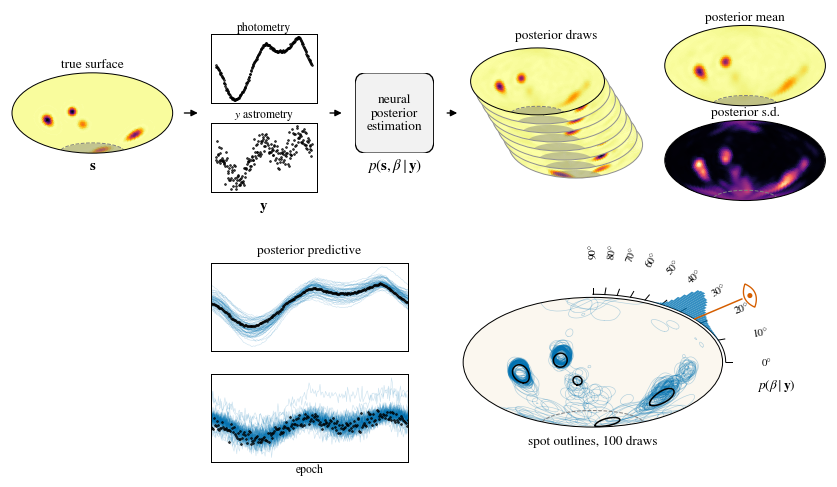

In [10]:
fig = plt.figure(figsize=(FIG_W, FIG_H), constrained_layout=False)

SW, SH, SGAP = 0.126, 0.135, 0.038   # row 1 signal panel and stack gap
# row 2 is sized on its own: longer in epoch than row 1, so the spread of the
# draws is legible along the series rather than only across it
PW, PH, PGAP = 0.235, 0.170, 0.045
MW = 0.192                           # truth, mean, s.d. map width
MH = MW / 2 * ASP
MGAP = 0.028                         # gap in the mean / s.d. stack
STACK_H = 2 * SH + SGAP

# ------------------------------------------------------------------- row 1
Y1c = 0.755
LAB_DROP = 0.032                     # symbol labels, beneath their element

x_t = 0.010
surf(fig, map_rect(x_t, Y1c, MW), truth, vlim=(vmin, vmax), shade=True,
     title='true surface')
fig.text(x_t + MW / 2, Y1c - MH / 2 - LAB_DROP, r'$\mathbf{s}$',
         ha='center', fontsize=9)

x_sig = 0.248
signal_stack(fig, x_sig, Y1c, SW, SH, SGAP,
             lambda a, k, c: a.plot(np.arange(T), obs_disp[k], 'k.', ms=1.0),
             titles=True)
fig.text(x_sig + SW / 2, Y1c - STACK_H / 2 - LAB_DROP, r'$\mathbf{y}$',
         ha='center', fontsize=9)

x_box, BW, BH = 0.420, 0.094, MH     # box height = the true-surface map height
ax_box = fig.add_axes([x_box, Y1c - BH / 2, BW, BH])
ax_box.set_axis_off()
ax_box.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                boxstyle='round,pad=0.02,rounding_size=0.14',
                                fc='#f2f2f2', ec='k', lw=0.8,
                                transform=ax_box.transAxes))
ax_box.text(0.5, 0.5, 'neural\nposterior\nestimation', ha='center',
            va='center', fontsize=8, transform=ax_box.transAxes)
fig.text(x_box + BW / 2, Y1c - BH / 2 - LAB_DROP,
         r'$p(\mathbf{s}, \beta \mid \mathbf{y})$', ha='center', fontsize=9)

fx, fw = 0.558, 0.160
fh = fw / 2 * ASP
fy = Y1c - fh / 2 - (N_FAN * FAN_DY) / 2
for j, s in enumerate(fan_idx[::-1]):
    depth = N_FAN - j
    surf(fig, [fx + depth * FAN_DX, fy + depth * FAN_DY, fw, fh], maps[s],
         vlim=(vmin, vmax), line=False, shade=True,
         alpha=FAN_ALPHA_MIN + (1 - FAN_ALPHA_MIN) * (j + 1) / N_FAN,
         edge='#909090')
surf(fig, [fx, fy, fw, fh], pm, vlim=(vmin, vmax), shade=True)
fig.text(fx + fw / 2 + N_FAN * FAN_DX / 2, fy + fh + 0.018, 'posterior draws',
         ha='center', fontsize=8)

x_ms = 0.790
surf(fig, [x_ms, Y1c + MGAP / 2, MW, MH], pm, vlim=(vmin, vmax), shade=True,
     title='posterior mean')
surf(fig, [x_ms, Y1c - MGAP / 2 - MH, MW, MH], ps, cmap=SD_CMAP,
     title='posterior s.d.')

arrow(fig, (x_t + MW + 0.010, Y1c), (x_sig - 0.012, Y1c))
arrow(fig, (x_sig + SW + 0.012, Y1c), (x_box - 0.012, Y1c))
arrow(fig, (x_box + BW + 0.012, Y1c), (fx - 0.012, Y1c))

# ------------------------------------------------------------------- row 2
Y2c = 0.272
xg = np.arange(T)

PSTACK_H = 2 * PH + PGAP


def draw_ppc(a, k, c):
    if PPC_STYLE == 'draws':
        for s_ in ppc_idx:
            a.plot(xg, pred_disp[s_, k], color=BLUE, lw=0.35,
                   alpha=min(0.55, 12.0 / len(ppc_idx)))
    else:
        q = np.quantile(pred_disp[:, k], [0.025, 0.16, 0.5, 0.84, 0.975],
                        axis=0)
        a.fill_between(xg, q[0], q[4], color=BLUE, alpha=0.20, lw=0)
        a.fill_between(xg, q[1], q[3], color=BLUE, alpha=0.42, lw=0)
        a.plot(xg, q[2], color=BLUE, lw=0.8)
    a.plot(xg, obs_disp[k], 'k.', ms=1.0)
    a.set_xlim(xg[0], xg[-1])
    if k == len(CHANNELS) - 1:
        a.set_xlabel('epoch', fontsize=7, labelpad=1)


signal_stack(fig, x_sig, Y2c, PW, PH, PGAP, draw_ppc)
fig.text(x_sig + PW / 2, Y2c + PSTACK_H / 2 + 0.018, 'posterior predictive',
         ha='center', fontsize=8)

# the outline composite and its arc, centred in the space to the right of the
# predictive stack
OW = 0.310
X_FREE = (x_sig + PW + 0.020, 0.995)
group_r = (OW / 2 * FIG_W * (1 + BAR_FRAC / 2)
           + BAR_PAD + LAB_GAP + 0.30) / FIG_W
cx = np.mean(X_FREE) - (group_r - OW / 2) / 2

a_out = map_axes(fig, map_rect(cx - OW / 2, Y2c, OW))
a_out.set_facecolor('#fbf7ef')
for s in contour_idx:
    for p in spot_outlines(maps[s]):
        a_out.plot(p[:, 0], p[:, 1], color=BLUE, lw=0.4, alpha=0.28)
for p in spot_outlines(truth):
    a_out.plot(p[:, 0], p[:, 1], color='k', lw=0.9)
cap_line(a_out)
_map_style(a_out)
# the arc sweeps into the lower right quadrant when north is up and the upper
# right when south is up, so the heading takes the side it has left free
_otitle = f'spot outlines, {N_CONTOUR} draws'
if UP == 'north':
    a_out.set_title(_otitle, fontsize=8, pad=3)
else:
    fig.text(cx, Y2c - OW / 4 * ASP - 0.034, _otitle, ha='center', fontsize=8)

A_ARC, B_ARC, HMAX_ARC, ARC_FEET = beta_arc(fig, cx, Y2c, OW)
check_arc(fig, a_out, cx, Y2c, A_ARC, B_ARC, ARC_FEET)

plt.show()


## Saving and caption numbers

In [11]:
stem = (f'fig01_headline_{PROJ}'
        + ('_south' if UP == 'south' else '')
        + ('_draws' if PPC_STYLE == 'draws' else ''))
save_fig(fig, stem)

print(f'family: {FAMILY}')
print(f'surface_idx {IDX}, slot {SLOT}')
print(f'projection: {PROJ} ({BOUNDARY} boundary), {UP} up; '
      f'predictive: {PPC_STYLE}')
print(f'visible spot count: {n_vis} (of {n_spots} injected)')
print(f'visible filling factor: {sff_vis:.4f}')
print(f'beta: true {beta_true:.0f} deg, recovered {b_med:.1f} '
      f'(+{b_hi - b_med:.1f}/-{b_med - b_lo:.1f}); arc spans '
      f'{BETA_LIM[0]:.0f} to {BETA_LIM[1]:.0f} deg, 68 per cent of it '
      f'inside {b_hi - b_lo:.1f} deg')
print(f'SSIM_vis of the posterior mean: {ssim_head:.4f} '
      f'(grid {GRID[0]} x {GRID[1]})')
print(f'draws shown: fan {len(fan_idx)}, outlines {len(contour_idx)}, '
      f'predictive {len(ppc_idx) if PPC_STYLE == "draws" else N_DRAWS} '
      f'of {N_DRAWS}')
print(f'noise point: ({LOG_SIGMA_PHOT}, {SIGMA_ASTRO_FIG}); the pinned '
      f'run is ({LOG_SIGMA_PHOT}, {LOG_SIGMA_ASTRO})')
print(f'spot outline level: {SPOT_LEVEL} '
      f'(metrics.spot_mask threshold is {metrics.SPOT_THRESHOLD})')
print(f'ink: posterior {BLUE}, truth {RED}, from OKABE_ITO')
print(f'photometry absolute-flux offset: {flux_off:+.3e} '
      f'relative flux units')


wrote notebooks/paper/figs/fig01_headline_aitoff_south_draws.pdf, notebooks/paper/figs/fig01_headline_aitoff_south_draws.png
family: phot_ay
surface_idx 45696, slot 2
projection: aitoff (ellipse boundary), south up; predictive: draws
visible spot count: 4 (of 5 injected)
visible filling factor: 0.0222
beta: true 23 deg, recovered 30.0 (+4.6/-6.4); arc spans 0 to 90 deg, 68 per cent of it inside 11.0 deg
SSIM_vis of the posterior mean: 0.9704 (grid 120 x 240)
draws shown: fan 7, outlines 100, predictive 60 of 256
noise point: (-4.0, -3.1); the pinned run is (-4.0, -3.5)
spot outline level: 0.93 (metrics.spot_mask threshold is 0.9)
ink: posterior #0072B2, truth #D55E00, from OKABE_ITO
photometry absolute-flux offset: -1.870e-03 relative flux units
